<a href="https://colab.research.google.com/github/sidhu2690/MARL/blob/main/Trust_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

GRID = 12
N_ROBOTS = 12
ADV_FRAC_MAX = 0.35
STEPS = 150
EPSILON = 0.05
CONTRA_THRESH = 0.2
EPISODES = 600
LR = 2e-3
SEED = 0

rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

def make_true_map(grid):
  xs, ys = np.meshgrid(np.arange(grid), np.arange(grid))
  field = np.zeros((grid, grid))
  for _ in range(5):
    cx, cy = rng.uniform(0, grid, 2)
    amp = rng.uniform(0.5, 1.0)
    sigma = rng.uniform(1.5, 3.5)
    field += amp * np.exp(-((xs - cx) ** 2 + (ys - cy) ** 2) / (2 * sigma ** 2))
  field = (field - field.min()) / (field.max() - field.min() + 1e-8)
  return field

def make_adv_mask(n_robots, n_adv):
  mask = np.array([False] * (n_robots - n_adv) + [True] * n_adv)
  rng.shuffle(mask)
  return mask

def random_walk(grid, steps):
  pos = rng.integers(0, grid, size=2)
  cells = []
  for _ in range(steps):
    while True:
      move = rng.choice([-1, 0, 1], size=2)
      new_pos = np.clip(pos + move, 0, grid - 1)
      if not np.array_equal(new_pos, pos):
        break
    pos = new_pos
    cells.append(tuple(pos))
  return cells

def report_value(true_val, adversarial):
  if adversarial:
    val = true_val + rng.choice([-1, 1]) * rng.uniform(0.3, 0.6)
    val += rng.normal(0, 0.1)
  else:
    val = true_val + rng.normal(0, 0.02)
  return float(np.clip(val, 0, 1))

In [8]:
class AlphaNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
      nn.Linear(3, 16),
      nn.ReLU(),
      nn.Linear(16, 8),
      nn.ReLU(),
      nn.Linear(8, 1),
      nn.Sigmoid(),
    )
  def forward(self, feats):
    return self.net(feats).squeeze(-1)

alpha_net = AlphaNet()
optimizer = torch.optim.Adam(alpha_net.parameters(), lr=LR)

loss_history = []

for ep in range(EPISODES):
  G = make_true_map(GRID)
  n_adv = rng.integers(1, int(N_ROBOTS * ADV_FRAC_MAX) + 1)
  is_adversarial = make_adv_mask(N_ROBOTS, n_adv)
  walks = [random_walk(GRID, STEPS) for _ in range(N_ROBOTS)]
  c = np.zeros(N_ROBOTS)
  D_sum = np.zeros(N_ROBOTS)
  D_n = np.zeros(N_ROBOTS)
  cell_reports = {}
  ep_loss = 0.0
  for t in range(STEPS):
    touched_cells = set()
    for i in range(N_ROBOTS):
      cell = walks[i][t]
      r_i = report_value(G[cell], is_adversarial[i])
      others = cell_reports.get(cell, [])
      if len(others) > 0:
        residuals = [abs(r_i - r_j) for _, r_j in others]
        D_sum[i] += float(np.mean(residuals))
        D_n[i] += 1
        for j, r_j in others:
          if abs(r_i - r_j) > CONTRA_THRESH:
            c[i] += 1
            c[j] += 1
      cell_reports.setdefault(cell, []).append((i, r_i))
      touched_cells.add(cell)
    mu_c, sigma_c = c.mean(), c.std()
    z = (c - mu_c) / (sigma_c + EPSILON)
    D = np.divide(D_sum, D_n, out=np.zeros_like(D_sum), where=D_n > 0)
    c_norm = c / (t + 1)
    feats = torch.tensor(np.stack([c_norm, z, D], axis=1), dtype=torch.float32)
    alpha = alpha_net(feats)
    step_loss = 0.0
    for cell in touched_cells:
      reports = cell_reports[cell]
      idx = torch.tensor([r for r, _ in reports])
      vals = torch.tensor([v for _, v in reports], dtype=torch.float32)
      a = alpha[idx]
      M = (a * vals).sum() / (a.sum() + EPSILON)
      step_loss = step_loss + (G[cell] - M) ** 2
    step_loss = step_loss / len(touched_cells)
    optimizer.zero_grad()
    step_loss.backward()
    optimizer.step()
    ep_loss += step_loss.item()
  loss_history.append(ep_loss / STEPS)
  if (ep + 1) % 50 == 0:
    print(f"episode {ep+1}/{EPISODES}  avg loss {loss_history[-1]:.5f}")

print("done, final loss:", loss_history[-1])

episode 50/600  avg loss 0.00720
episode 100/600  avg loss 0.00677
episode 150/600  avg loss 0.00666
episode 200/600  avg loss 0.00530
episode 250/600  avg loss 0.00375
episode 300/600  avg loss 0.00056
episode 350/600  avg loss 0.00383
episode 400/600  avg loss 0.00301
episode 450/600  avg loss 0.00629
episode 500/600  avg loss 0.00297
episode 550/600  avg loss 0.00198
episode 600/600  avg loss 0.00531
done, final loss: 0.005310789551355507


In [9]:
# Test 1: classification accuracy of alpha (honest vs adversarial), varying n_adv per trial

N_TEST_ROBOTS = 12
N_TEST_TRIALS = 30
N_ADV_MAX = 4

all_c_norm, all_z, all_D, all_labels = [], [], [], []

for trial in range(N_TEST_TRIALS):
  G = make_true_map(GRID)
  n_adv = rng.integers(1, N_ADV_MAX + 1)
  is_adv = make_adv_mask(N_TEST_ROBOTS, n_adv)
  walks = [random_walk(GRID, STEPS) for _ in range(N_TEST_ROBOTS)]
  c = np.zeros(N_TEST_ROBOTS)
  D_sum = np.zeros(N_TEST_ROBOTS)
  D_n = np.zeros(N_TEST_ROBOTS)
  cell_reports = {}
  for t in range(STEPS):
    for i in range(N_TEST_ROBOTS):
      cell = walks[i][t]
      r_i = report_value(G[cell], is_adv[i])
      others = cell_reports.get(cell, [])
      if others:
        residuals = [abs(r_i - r_j) for _, r_j in others]
        D_sum[i] += np.mean(residuals)
        D_n[i] += 1
        for j, r_j in others:
          if abs(r_i - r_j) > CONTRA_THRESH:
            c[i] += 1
            c[j] += 1
      cell_reports.setdefault(cell, []).append((i, r_i))
    mu_c, sigma_c = c.mean(), c.std()
    z = (c - mu_c) / (sigma_c + EPSILON)
    D = np.divide(D_sum, D_n, out=np.zeros_like(D_sum), where=D_n > 0)
    c_norm = c / (t + 1)
    all_c_norm.append(c_norm.copy())
    all_z.append(z.copy())
    all_D.append(D.copy())
    all_labels.append(is_adv.copy())

c_norm_all = np.concatenate(all_c_norm)
z_all = np.concatenate(all_z)
D_all = np.concatenate(all_D)
labels = np.concatenate(all_labels).astype(float)

feats_test = torch.tensor(np.stack([c_norm_all, z_all, D_all], axis=1), dtype=torch.float32)
with torch.no_grad():
  alpha_pred = alpha_net(feats_test).numpy()

pred_labels = (alpha_pred < 0.5).astype(float)
accuracy = (pred_labels == labels).mean()

print(f"accuracy: {accuracy:.4f}")
print(f"mean alpha (honest gt): {alpha_pred[labels == 0].mean():.4f}")
print(f"mean alpha (adv gt):    {alpha_pred[labels == 1].mean():.4f}")

tp = ((pred_labels == 1) & (labels == 1)).sum()
fp = ((pred_labels == 1) & (labels == 0)).sum()
fn = ((pred_labels == 0) & (labels == 1)).sum()
tn = ((pred_labels == 0) & (labels == 0)).sum()
print(f"confusion matrix -> TP:{tp} FP:{fp} FN:{fn} TN:{tn}")

accuracy: 0.9854
mean alpha (honest gt): 0.9904
mean alpha (adv gt):    0.0853
confusion matrix -> TP:10534 FP:372 FN:416 TN:42678


saved plot to alpha_vs_adv_count.png


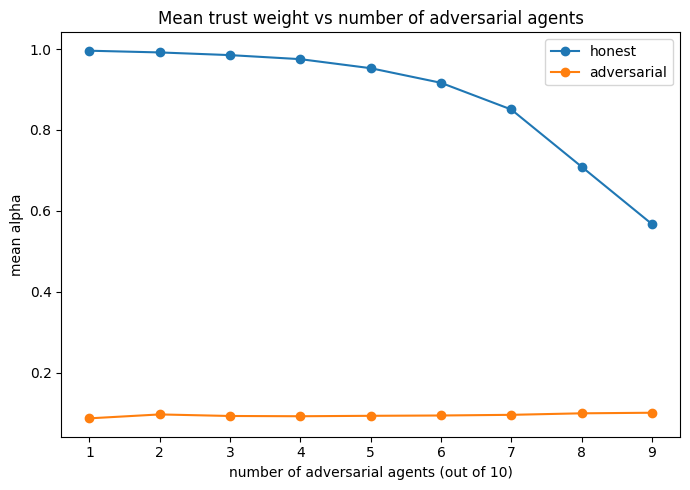

In [10]:
# Test 2: mean alpha vs number of adversarial agents

N_ROBOTS_FIXED = 10
adv_counts = np.arange(1, 10)
N_TRIALS = 100

honest_alpha_curve = []
adv_alpha_curve = []

for n_adv in adv_counts:
  honest_trials = []
  adv_trials = []
  for _ in range(N_TRIALS):
    G = make_true_map(GRID)
    is_adv = make_adv_mask(N_ROBOTS_FIXED, n_adv)
    walks = [random_walk(GRID, STEPS) for _ in range(N_ROBOTS_FIXED)]
    c = np.zeros(N_ROBOTS_FIXED)
    D_sum = np.zeros(N_ROBOTS_FIXED)
    D_n = np.zeros(N_ROBOTS_FIXED)
    cell_reports = {}
    honest_alpha_over_time = []
    adv_alpha_over_time = []
    for t in range(STEPS):
      for i in range(N_ROBOTS_FIXED):
        cell = walks[i][t]
        r_i = report_value(G[cell], is_adv[i])
        others = cell_reports.get(cell, [])
        if others:
          residuals = [abs(r_i - r_j) for _, r_j in others]
          D_sum[i] += np.mean(residuals)
          D_n[i] += 1
          for j, r_j in others:
            if abs(r_i - r_j) > CONTRA_THRESH:
              c[i] += 1
              c[j] += 1
        cell_reports.setdefault(cell, []).append((i, r_i))
      mu_c, sigma_c = c.mean(), c.std()
      z = (c - mu_c) / (sigma_c + EPSILON)
      D = np.divide(D_sum, D_n, out=np.zeros_like(D_sum), where=D_n > 0)
      c_norm = c / (t + 1)
      feats = torch.tensor(np.stack([c_norm, z, D], axis=1), dtype=torch.float32)
      with torch.no_grad():
        alpha = alpha_net(feats).numpy()
      honest_alpha_over_time.append(alpha[~is_adv].mean())
      adv_alpha_over_time.append(alpha[is_adv].mean())
    honest_trials.append(np.mean(honest_alpha_over_time))
    adv_trials.append(np.mean(adv_alpha_over_time))
  honest_alpha_curve.append(np.mean(honest_trials))
  adv_alpha_curve.append(np.mean(adv_trials))

plt.figure(figsize=(7, 5))
plt.plot(adv_counts, honest_alpha_curve, marker='o', label='honest')
plt.plot(adv_counts, adv_alpha_curve, marker='o', label='adversarial')
plt.xlabel("number of adversarial agents (out of 10)")
plt.ylabel("mean alpha")
plt.title("Mean trust weight vs number of adversarial agents")
plt.legend()
plt.tight_layout()
plt.savefig("alpha_vs_adv_count.png", dpi=130)
print("saved plot to alpha_vs_adv_count.png")